# Confidence Interval

We'll see how to use **Bootstrapping** to calculate the **95% Confidence Interval**.

Data scientists would use this information:

1. to communicate the potential error in an estimate
2. to learn whether a larger sample is needed

In [1]:
import pandas as pd

## Bootstrapping

In modern statistics, the bootstrap has become the standard way to estimate standard error:

1. it can be used for virtually any statistic and
2. does not rely on any distributional assumptions (such as data being normally distributed)

You'll find a a step-by-step breakdown in `utils.bootstraps_mean` which returns:

1. `mean` of bootstrap means
2. standard error `se`
3. confidence interval `(ci_lower, ci_upper)` (default confidence level is 95%)

In [2]:
from utils import bootstraps_mean

For reference see [scipy.stats.bootstrap](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.bootstrap.html) and it's [source code](https://github.com/scipy/scipy/blob/cadff2794c526d283f0c048e3c19d8b960d9e415/scipy/stats/_resampling.py#L300) implementation.

### Apply on adults `hours-per-week` numerical value

In [3]:
from pathlib import Path

data_path = Path('../data/adult.csv')
data_path.exists()

True

In [4]:
df_raw = pd.read_csv(data_path)
df = df_raw[['hours-per-week', 'age']]
df

,hours-per-week,age
0,40,39
1,13,50
2,40,38
3,40,53
4,40,28
...,...,...
32556,38,27
32557,40,40
32558,40,58
32559,20,22


Set `trace=True` to see how the procedure executes

In [5]:
mean, se, ci = bootstraps_mean(
    df['hours-per-week'],
    n_resamples=1000,
    confidence_level=95,
    trace=True
)

Bootstrapping 1000 samples...
The 0-th sample of size 30 is bootstrapped...
The 10-th sample of size 30 is bootstrapped...
The 20-th sample of size 30 is bootstrapped...
The 30-th sample of size 30 is bootstrapped...
The 40-th sample of size 30 is bootstrapped...
The 50-th sample of size 30 is bootstrapped...
The 60-th sample of size 30 is bootstrapped...
The 70-th sample of size 30 is bootstrapped...
The 80-th sample of size 30 is bootstrapped...
The 90-th sample of size 30 is bootstrapped...
The 100-th sample of size 30 is bootstrapped...
The 110-th sample of size 30 is bootstrapped...
The 120-th sample of size 30 is bootstrapped...
The 130-th sample of size 30 is bootstrapped...
The 140-th sample of size 30 is bootstrapped...
The 150-th sample of size 30 is bootstrapped...
The 160-th sample of size 30 is bootstrapped...
The 170-th sample of size 30 is bootstrapped...
The 180-th sample of size 30 is bootstrapped...
The 190-th sample of size 30 is bootstrapped...
The 200-th sample of 

In [6]:
print("For hours per week:-")
print(f"Sampling Distribution Mean  = {mean:.1f}")
print(f"Standard Error              = {se:.1f}")
print(f"The 95% Confidence Interval = ({ci[0]:.1f}, {ci[1]:.1f})")

For hours per week:-
Sampling Distribution Mean  = 40.4
Standard Error              = 2.2
The 95% Confidence Interval = (36.1, 44.7)


Thus the probability that the population average `hours-per-week` lies between (36.1, 44.7) is: 95%.

In mathematical terms:

$$ P(\mu_\text{hours-per-week} \in (36.1, 44.7)) = 0.95 $$

### Apply on adults `age`

In [7]:
mean, se, ci, bootstrap_means = bootstraps_mean(df['age'], n_resamples=999, confidence_level=95, return_bootstrap_means=True)

In [8]:
print("For age:-")
print(f"Sampling Distribution Mean  = {mean:.1f}")
print(f"Standard Error              = {se:.1f}")
print(f"The 95% Confidence Interval = ({ci[0]:.1f}, {ci[1]:.1f})")

For age:-
Sampling Distribution Mean  = 38.5
Standard Error              = 2.5
The 95% Confidence Interval = (33.8, 43.6)


Thus the probability that the population average `age` lies between (33.8, 43.6) is: 95%.

In mathematical terms:

$$ P(\mu_\text{age} \in (33.8, 43.6)) = 0.95 $$

#### Visualize Sampling Distribution

- Left: distribution of the variable (`age`) itself
- Right: distribution of the statistic (`mean_age`) for `n_resamples=999`

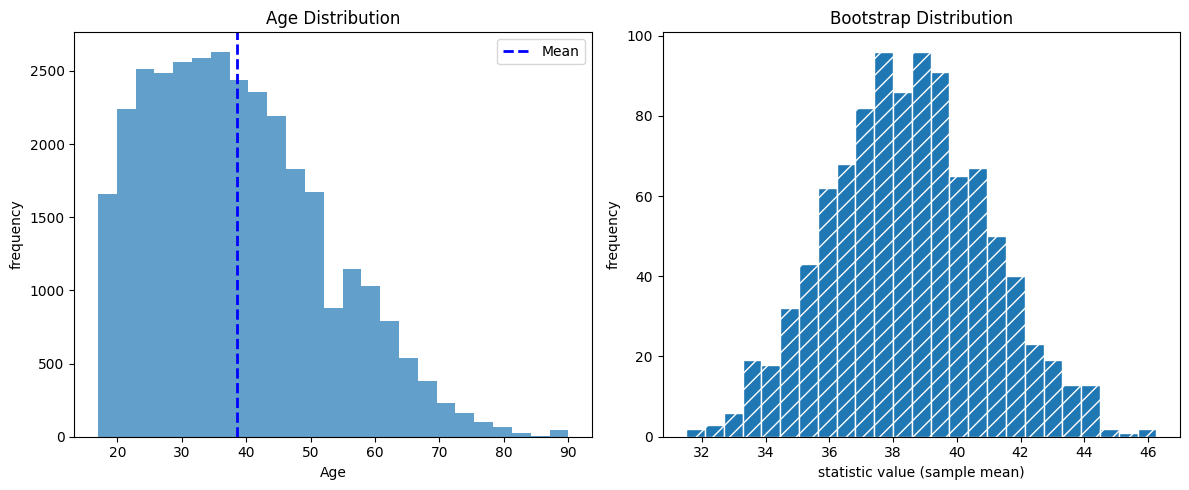

In [9]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 1. Plot Age distribution itself
axes[0].hist(df['age'], bins=25, alpha=0.7)
axes[0].axvline(df['age'].mean(), color='blue', linestyle='dashed', linewidth=2, label='Mean')
axes[0].set_title('Age Distribution')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('frequency')
axes[0].legend()

# 2. Plot bootstrap distribution (keep as is)
axes[1].hist(bootstrap_means, bins=25, hatch='//', edgecolor='white')
axes[1].set_title('Bootstrap Distribution')
axes[1].set_xlabel('statistic value (sample mean)')
axes[1].set_ylabel('frequency')

plt.tight_layout()
plt.show()

### Standard Deviation vs. Versus Standard Error

Do not confuse standard deviation (which measures the variability of individual data points) with standard error (which measures the variability of a sample metric).

In [11]:
print(f"Standard Deviation is about age variable (left): {df['age'].std():0.2f}")
print(f"Standard Error is about mean_age statistic (right): {se:0.2f}")

Standard Deviation is about age variable (left): 13.64
Standard Error is about mean_age statistic (right): 2.46
